# Train ECAPA-TDNN for Speech Emotion Recognition

This notebook implements training of an ECAPA-TDNN model using the SpeechBrain library.
Dataset: `DATASET_LABELED` (Structured as `Emotion/Filename.wav`)

In [12]:
import os
import glob
import random
import json
import torch
import torchaudio
import speechbrain as sb
import numpy as np
from collections import Counter
from speechbrain.inference.classifiers import EncoderClassifier
from speechbrain.lobes.models.ECAPA_TDNN import ECAPA_TDNN

# Check CUDA
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 1. Setup Data Manifest (Train/Valid Split)
SpeechBrain requires a data manifest (JSON/CSV) to load data. Use 80/20 Split.

In [13]:
DATA_DIR = "../DATASET_LABELED"
JSON_SAVE_DIR = "./ecapa_finetune_results_v2" 
os.makedirs(JSON_SAVE_DIR, exist_ok=True)

def create_json_manifests(data_dir, train_json, valid_json, split_ratio=0.8):
    if os.path.exists(train_json) and os.path.exists(valid_json):
        print(f"Manifests already exist. Skipping creation.")
        return
    
    wav_list = glob.glob(os.path.join(data_dir, "*", "*.wav"))
    print(f"Found {len(wav_list)} files in {data_dir}")
    
    # Shuffle and split
    random.seed(42)
    random.shuffle(wav_list)
    split_idx = int(len(wav_list) * split_ratio)
    train_files = wav_list[:split_idx]
    valid_files = wav_list[split_idx:]
    
    print(f"Splitting: {len(train_files)} Train, {len(valid_files)} Valid")
    
    for output_json, files in [(train_json, train_files), (valid_json, valid_files)]:
        json_dict = {}
        for wav_file in files:
            # Format: ../DATASET_LABELED/Emotion/filename.wav
            parts = os.path.normpath(wav_file).split(os.sep)
            emotion = parts[-2]
            filename = parts[-1]
            utt_id = os.path.splitext(filename)[0]
            
            # Get duration
            info = torchaudio.info(wav_file)
            duration = info.num_frames / info.sample_rate
            
            json_dict[utt_id] = {
                "wav": wav_file,
                "duration": duration,
                "emotion": emotion
            }
            
        with open(output_json, "w") as f:
            json.dump(json_dict, f, indent=2)
        print(f"Created manifest at {output_json} with {len(json_dict)} entries")

TRAIN_JSON = os.path.join(JSON_SAVE_DIR, "train.json")
VALID_JSON = os.path.join(JSON_SAVE_DIR, "valid.json")

create_json_manifests(DATA_DIR, TRAIN_JSON, VALID_JSON)

Found 1678 files in ../DATASET_LABELED
Splitting: 1342 Train, 336 Valid
Created manifest at ./ecapa_finetune_results_v2\train.json with 1336 entries
Created manifest at ./ecapa_finetune_results_v2\valid.json with 335 entries


## 2. Define Brain Class
This class defines how the model trains and validates.

In [14]:
class SERBrain(sb.Brain):
    def compute_forward(self, batch, stage):
        batch = batch.to(self.device)
        wavs, lens = batch.sig 
        
        # Feature extraction
        feats = self.modules.compute_features(wavs)
        feats = self.modules.mean_var_norm(feats, lens)
        
        # Bật lại SpecAugment cho tập Train
        if stage == sb.Stage.TRAIN:
             feats = self.hparams.spec_augment(feats)
        
        # Embeddings
        outputs = self.modules.embedding_model(feats, lens)
        
        # Classifier
        outputs = self.modules.classifier(outputs)
        
        return outputs

    def compute_objectives(self, predictions, batch, stage):
        emotions, _ = batch.emotion_encoded
        
        # Calculate Loss using torch.nn.CrossEntropyLoss
        # It expects class indices, not one-hot encoding
        if len(emotions.shape) > 1 and emotions.shape[-1] == 1:
             emotions = emotions.squeeze(-1)
             
        loss = self.hparams.compute_cost(predictions, emotions)

        if stage != sb.Stage.TRAIN:
            self.error_metrics.append(batch.id, predictions, emotions)

        return loss

    def on_stage_start(self, stage, epoch):
        if stage != sb.Stage.TRAIN:
            self.error_metrics = self.hparams.error_stats
            self.error_metrics.clear()

    def on_stage_end(self, stage, stage_loss, epoch):
        if stage == sb.Stage.TRAIN:
            self.train_loss = stage_loss
        else:
            stats = {
                "loss": stage_loss,
                "error": self.error_metrics.summarize("average")
            }
            
            if stage == sb.Stage.VALID:
                old_lr, new_lr = self.hparams.lr_annealing(stats["error"])
                sb.nnet.schedulers.update_learning_rate(self.optimizer, new_lr)
                
                # Save checkpoint
                self.checkpointer.save_and_keep_only(
                    meta=stats, min_keys=["error"]
                )
            
            print(f"Epoch: {epoch}, Stage: {stage}, Stats: {stats}")

## 3. Configuration & Hyperparameters

In [15]:
from speechbrain.lobes.features import Fbank
from speechbrain.processing.features import InputNormalization
import torchaudio.transforms as T

# 1. Feature extraction
compute_features = Fbank(n_mels=80)

# 2. Normalization
mean_var_norm = InputNormalization(norm_type="sentence", std_norm=False)

# 3. Custom SpecAugment using Torchaudio
class CustomSpecAugment(torch.nn.Module):
    def __init__(self, time_mask_param=10, freq_mask_param=10):
        super().__init__()
        # Giảm parameter xuống 10 (từ 15)
        self.time_masking = T.TimeMasking(time_mask_param=time_mask_param)
        self.freq_masking = T.FrequencyMasking(freq_mask_param=freq_mask_param)
    def forward(self, x):
        # Apply với xác suất 50% để tránh che quá nhiều thông tin
        if self.training and torch.rand(1) < 0.5:
             return x
             
        # x: (batch, time, freq)
        x = x.transpose(1, 2) # (batch, freq, time)
        x = self.freq_masking(x)
        x = self.time_masking(x)
        x = x.transpose(1, 2)
        return x
spec_augment = CustomSpecAugment()

# 4. Embedding Model (PRETRAINED ECAPA-TDNN)
print("Downloading/Loading Pretrained Model...")
pretrained_source = "speechbrain/spkrec-ecapa-voxceleb"
pretrained_encoder = EncoderClassifier.from_hparams(
    source=pretrained_source, 
    run_opts={"device": device}
)
# Extract embedding model
embedding_model = pretrained_encoder.mods.embedding_model
# QUAN TRỌNG: Unfreeze toàn bộ model để fine-tune tốt hơn
for param in embedding_model.parameters():
    param.requires_grad = True

# 5. Classifier (UPGRADED to MLP)
# Replace simple Linear layer with a stronger implementation
class EmotionClassifier(torch.nn.Module):
    def __init__(self, input_dim=192, hidden_dim=128, out_dim=5, dropout=0.5):
        super().__init__()
        self.layer1 = torch.nn.Linear(input_dim, hidden_dim)
        self.bn1 = torch.nn.BatchNorm1d(hidden_dim)
        self.act1 = torch.nn.LeakyReLU()
        self.dropout = torch.nn.Dropout(p=dropout)
        self.layer2 = torch.nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        # x shape: [batch, 1, 192] -> squeeze to [batch, 192]
        x = x.squeeze(1) 
        x = self.layer1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.dropout(x)
        x = self.layer2(x)
        # Output shape: [batch, out_dim]
        return x

classifier = EmotionClassifier(input_dim=192, hidden_dim=128, out_dim=5)

# 6. Modules dictionary
modules = {
    "compute_features": compute_features,
    "mean_var_norm": mean_var_norm,
    "spec_augment": spec_augment, # Add to modules for CUDA moving
    "embedding_model": embedding_model,
    "classifier": classifier
}

# 7. Optimization
# Use a smaller Learning Rate for Fine-tuning
opt_class = torch.optim.Adam
lr_annealing = sb.nnet.schedulers.NewBobScheduler(initial_value=0.0001) 

# Define error metric with reduction='none' for MetricStats
def error_metric_fn(predictions, targets):
    return sb.nnet.losses.classification_error(predictions, targets, reduction="none")

error_stats = sb.utils.metric_stats.MetricStats(metric=error_metric_fn)
epoch_counter = sb.utils.epoch_loop.EpochCounter(limit=50) # Increased to 50

hparams = {
    "compute_features": compute_features,
    "mean_var_norm": mean_var_norm,
    "spec_augment": spec_augment,
    "embedding_model": embedding_model,
    "classifier": classifier,
    "lr_annealing": lr_annealing,
    "error_stats": error_stats,
    "epoch_counter": epoch_counter,
    "dataloader_options": {"batch_size": 8, "shuffle": True, "drop_last": True},
}

# Checkpointer
checkpointer = sb.utils.checkpoints.Checkpointer(
    checkpoints_dir=os.path.join(JSON_SAVE_DIR, "save"),
    recoverables={
        "embedding_model": embedding_model,
        "classifier": classifier,
        "counter": epoch_counter,
    }
)

Downloading/Loading Pretrained Model...


e:\anaconda3\envs\ser\lib\site-packages\speechbrain\utils\checkpoints.py:200: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(path, map_location=device

## 4. Run Training

In [16]:
# Load datasets
datasets = {}
# Load from separate JSON files
data_info = {
    "train": TRAIN_JSON,
    "valid": VALID_JSON,
}

# Label Encoder
label_encoder = sb.dataio.encoder.CategoricalEncoder()

# Dynamic Item Dataset
from speechbrain.dataio.dataset import DynamicItemDataset

@sb.utils.data_pipeline.takes("emotion")
@sb.utils.data_pipeline.provides("emotion_encoded")
def audio_pipeline(emotion):
    return label_encoder.encode_label_torch(emotion)

@sb.utils.data_pipeline.takes("wav")
@sb.utils.data_pipeline.provides("sig")
def signal_pipeline(wav):
    sig = sb.dataio.dataio.read_audio(wav)
    # Resample if needed inside pipeline or pre-check. Assuming 16k.
    return sig

# create datasets
for split in ["train", "valid"]:
    dataset = DynamicItemDataset.from_json(json_path=data_info[split], replacements={})
    dataset.add_dynamic_item(audio_pipeline)
    dataset.add_dynamic_item(signal_pipeline)
    dataset.set_output_keys(["id", "sig", "emotion_encoded"])
    datasets[split] = dataset

# Update Label Encoder (using ONLY training data)
label_encoder.update_from_didataset(datasets["train"], output_key="emotion")
print(f"Labels: {label_encoder.ind2lab}")

# ---------- CALCULATE CLASS WEIGHTS ----------
# Get all labels from training set to calculate weights
all_emotions = []
with open(TRAIN_JSON, "r") as f:
    data = json.load(f)
    for key in data:
        all_emotions.append(data[key]["emotion"])

# Count frequencies
counts = Counter(all_emotions)
print(f"Class counts: {counts}")

# Sort counts by encoder index to match output layer
weights_list = []
total_samples = sum(counts.values())
for i in range(len(label_encoder)):
    label = label_encoder.ind2lab[i]
    weight = total_samples / (len(counts) * counts.get(label, 1))
    weights_list.append(weight)

class_weights = torch.FloatTensor(weights_list).to(device)
print(f"Class Weights: {class_weights}")

# Use weighted CrossEntropyLoss
compute_cost = torch.nn.CrossEntropyLoss(weight=class_weights)
hparams["compute_cost"] = compute_cost # Update loss function in hparams

# Initialize Brain
ser_brain = SERBrain(
    modules=modules,
    opt_class=opt_class,
    hparams=hparams,
    run_opts={"device": device},
    checkpointer=checkpointer
)


Labels: {0: 'SAD', 1: 'NEU', 2: 'ANG', 3: 'HAP', 4: 'ANX'}
Class counts: Counter({'NEU': 604, 'ANG': 241, 'HAP': 183, 'ANX': 157, 'SAD': 151})
Class Weights: tensor([1.7695, 0.4424, 1.1087, 1.4601, 1.7019], device='cuda:0')


In [17]:
# Fit
ser_brain.fit(
    epoch_counter=ser_brain.hparams.epoch_counter,
    train_set=datasets["train"],
    valid_set=datasets["valid"],
    train_loader_kwargs=hparams["dataloader_options"],
    valid_loader_kwargs=hparams["dataloader_options"]
)

100%|██████████| 41/41 [00:04<00:00,  9.30it/s]


Epoch: 1, Stage: Stage.VALID, Stats: {'loss': 1.0580840590523513, 'error': 0.3445121943950653}


100%|██████████| 41/41 [00:04<00:00, 10.05it/s]


Epoch: 2, Stage: Stage.VALID, Stats: {'loss': 0.9929196776413336, 'error': 0.332317054271698}


100%|██████████| 41/41 [00:04<00:00, 10.04it/s]


...

Epoch: 48, Stage: Stage.VALID, Stats: {'loss': 0.9069430137552865, 'error': 0.3140243887901306}


100%|██████████| 41/41 [00:04<00:00,  9.87it/s]


Epoch: 49, Stage: Stage.VALID, Stats: {'loss': 0.9216445110193114, 'error': 0.29573169350624084}


100%|██████████| 41/41 [00:04<00:00, 10.06it/s]


Epoch: 50, Stage: Stage.VALID, Stats: {'loss': 0.9080153492892662, 'error': 0.31707316637039185}


## 5. Model Evaluation

Evaluate the trained model with Confusion Matrix, Classification Report and Per-Class Accuracy.

In [18]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Set model to evaluation mode
embedding_model.eval()
classifier.eval()

print("Model set to evaluation mode.")

Model set to evaluation mode.


In [19]:
# ---------- RUN INFERENCE ON VALIDATION SET ----------
# Reload validation dataset with emotion string for display
valid_dataset_eval = DynamicItemDataset.from_json(json_path=VALID_JSON, replacements={})
valid_dataset_eval.add_dynamic_item(audio_pipeline)
valid_dataset_eval.add_dynamic_item(signal_pipeline)
valid_dataset_eval.set_output_keys(["id", "sig", "emotion_encoded", "emotion"])

# Create DataLoader
valid_loader = sb.dataio.dataloader.make_dataloader(
    valid_dataset_eval, batch_size=1, shuffle=False
)

all_preds = []
all_labels = []

print("Running inference on validation set...")
with torch.no_grad():
    for batch in tqdm(valid_loader):
        wavs, lens = batch.sig
        wavs = wavs.to(device)
        lens = lens.to(device)
        
        # Feature extraction
        feats = compute_features(wavs)
        feats = mean_var_norm(feats, lens)
        
        # Embedding
        embeddings = embedding_model(feats, lens)
        
        # Classification
        logits = classifier(embeddings)
        pred = torch.argmax(logits, dim=-1)
        
        # Get true label
        true_label, _ = batch.emotion_encoded
        true_label = true_label.squeeze()
        
        all_preds.append(pred.cpu().item())
        all_labels.append(true_label.cpu().item())

print(f"Inference complete! Processed {len(all_preds)} samples.")

Running inference on validation set...


100%|██████████| 335/335 [00:06<00:00, 55.46it/s]

Inference complete! Processed 335 samples.


In [20]:
# ---------- CALCULATE METRICS ----------
# Get label names in order
label_names = [label_encoder.ind2lab[i] for i in range(len(label_encoder))]

# Overall Accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f"\n{'='*50}")
print(f"OVERALL ACCURACY: {accuracy*100:.2f}%")
print(f"{'='*50}")

# Classification Report
print("\nCLASSIFICATION REPORT:")
print("-" * 50)
report = classification_report(all_labels, all_preds, target_names=label_names, digits=4)
print(report)


OVERALL ACCURACY: 68.06%

CLASSIFICATION REPORT:
--------------------------------------------------
              precision    recall  f1-score   support

         SAD     0.8500    0.7907    0.8193        43
         NEU     0.7421    0.7919    0.7662       149
         ANG     0.6949    0.6508    0.6721        63
         HAP     0.4400    0.3333    0.3793        33
         ANX     0.4615    0.5106    0.4848        47

    accuracy                         0.6806       335
   macro avg     0.6377    0.6155    0.6244       335
weighted avg     0.6780    0.6806    0.6778       335



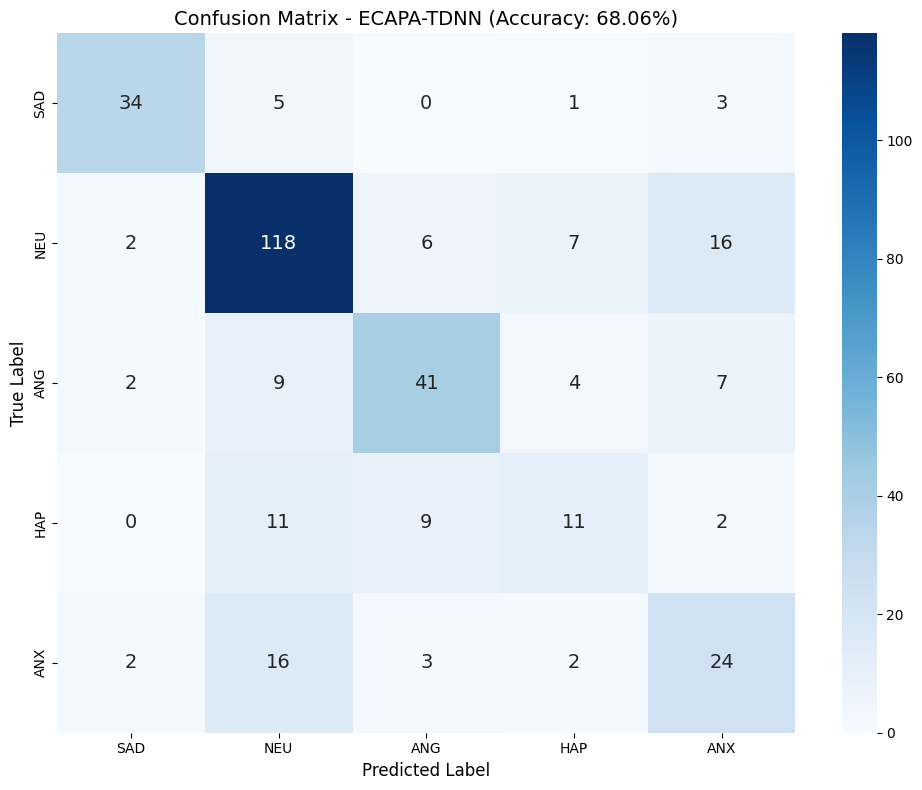


Confusion Matrix saved to: ./ecapa_finetune_results_v2\confusion_matrix.png


In [21]:
# ---------- CONFUSION MATRIX ----------
cm = confusion_matrix(all_labels, all_preds)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names,
    annot_kws={"size": 14}
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix - ECAPA-TDNN (Accuracy: {accuracy*100:.2f}%)', fontsize=14)
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(JSON_SAVE_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

print(f"\nConfusion Matrix saved to: {os.path.join(JSON_SAVE_DIR, 'confusion_matrix.png')}")

In [22]:
# ---------- PER-CLASS ACCURACY ----------
print("\nPER-CLASS ACCURACY:")
print("-" * 40)

for i, label in enumerate(label_names):
    # Count correct predictions for this class
    class_total = sum(1 for l in all_labels if l == i)
    class_correct = sum(1 for p, l in zip(all_preds, all_labels) if p == l == i)
    
    if class_total > 0:
        class_acc = class_correct / class_total * 100
        print(f"{label:>10}: {class_acc:6.2f}% ({class_correct}/{class_total})")
    else:
        print(f"{label:>10}: N/A (0 samples)")


PER-CLASS ACCURACY:
----------------------------------------
       SAD:  79.07% (34/43)
       NEU:  79.19% (118/149)
       ANG:  65.08% (41/63)
       HAP:  33.33% (11/33)
       ANX:  51.06% (24/47)
